In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from timeit import default_timer as timer

from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, AvgPool2D, BatchNormalization, Reshape # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.callbacks import LearningRateScheduler # type: ignore

import os
for dirname, _, filenames in os.walk('/media/yassin/Nuevo vol/Datasets/traffic/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print(os.listdir('/media/yassin/Nuevo vol/Datasets/traffic/'))

2025-09-13 11:46:31.280446: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/media/yassin/Nuevo vol/Datasets/traffic/data0.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data1.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data2.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data3.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data4.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data5.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data6.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data7.pickle
/media/yassin/Nuevo vol/Datasets/traffic/data8.pickle
/media/yassin/Nuevo vol/Datasets/traffic/datasets_preparing.py
/media/yassin/Nuevo vol/Datasets/traffic/labels.pickle
/media/yassin/Nuevo vol/Datasets/traffic/label_names.csv
/media/yassin/Nuevo vol/Datasets/traffic/mean_image_gray.pickle
/media/yassin/Nuevo vol/Datasets/traffic/mean_image_rgb.pickle
/media/yassin/Nuevo vol/Datasets/traffic/std_gray.pickle
/media/yassin/Nuevo vol/Datasets/traffic/std_rgb.pickle
/media/yassin/Nuevo vol/Datasets/traffic/test.pickle
/media/yassin/Nuevo vol/Datasets/traffic/train

In [2]:
# Data division
 
with open('/media/yassin/Nuevo vol/Datasets/traffic/data2.pickle', 'rb') as f:
    data = pickle.load(f, encoding='latin1')  # dictionary type

data['y_train'] = to_categorical(data['y_train'], num_classes=43)
data['y_validation'] = to_categorical(data['y_validation'], num_classes=43)

data['x_train'] = data['x_train'].transpose(0, 2, 3, 1)
data['x_validation'] = data['x_validation'].transpose(0, 2, 3, 1)
data['x_test'] = data['x_test'].transpose(0, 2, 3, 1)

for i, j in data.items():
    if i == 'labels':
        print(i + ':', len(j))
    else: 
        print(i + ':', j.shape)

y_test: (12630,)
y_validation: (4410, 43)
x_validation: (4410, 32, 32, 3)
x_train: (86989, 32, 32, 3)
y_train: (86989, 43)
labels: 43
x_test: (12630, 32, 32, 3)


In [3]:
# Building the model

model = Sequential()
model.add(Conv2D(32, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPool2D(pool_size=2))
model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dense(43, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/home/yassin/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1757756817.350482    3553 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5214 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** (x + epochs))
epochs = 15
n_images = 8000

h = model.fit(data['x_train'][:n_images], data['y_train'][:n_images],
              batch_size=5, epochs = epochs,
              validation_data = (data['x_validation'], data['y_validation']),
              callbacks=[annealer], verbose=1)

Epoch 1/15


2025-09-13 11:47:00.744103: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ff864007190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-13 11:47:00.744144: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-09-13 11:47:00.766587: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-13 11:47:00.907648: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-09-13 11:47:02.178135: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_216', 8 bytes spill stores, 8 bytes spill loads



  38/1600 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0250 - loss: 3.8202    

I0000 00:00:1757756825.225419    6979 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1600/1600 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.2560 - loss: 2.7681 - val_accuracy: 0.6206 - val_loss: 1.2681 - learning_rate: 4.6329e-04
Epoch 2/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7826 - loss: 0.8119 - val_accuracy: 0.7259 - val_loss: 1.0236 - learning_rate: 4.4013e-04
Epoch 3/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8945 - loss: 0.4273 - val_accuracy: 0.7583 - val_loss: 0.9709 - learning_rate: 4.1812e-04
Epoch 4/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9368 - loss: 0.2588 - val_accuracy: 0.7340 - val_loss: 0.9927 - learning_rate: 3.9721e-04
Epoch 5/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9566 - loss: 0.1795 - val_accuracy: 0.7882 - val_loss: 0.8732 - learning_rate: 3.7735e-04
Epoch 6/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9694 - loss: 0.1282 - val_accuracy: 0.8005 - val_loss: 0.8420 - learning_rate: 3.5849e-04
Epoch 7/15
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accu

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27237538..0.395523].


(1, 32, 32, 3)
[31]


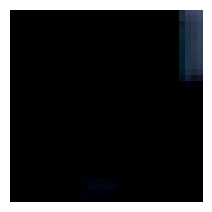

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
(43,)
ClassId: 31
Label: Wild animals crossing


In [18]:
imageID = 39
%matplotlib inline

# Preparing image for predicting from test dataset
x_input = data['x_test'][imageID:imageID+1]
print(x_input.shape)
y_input = data['y_test'][imageID:imageID+1]
print(y_input)

plt.rcParams['figure.figsize'] = (2.5, 2.5) # Setting default size of plots
plt.imshow(x_input[0, :, :, :])
plt.axis('off')

# Showing the plot
plt.show()

# Getting scores from forward pass of input image
scores = model.predict(x_input)
print(scores[0].shape) # (43,)

# Scores is given for image with 43 numbers of predictions for each class
# Getting only one class with maximum value
prediction = np.argmax(scores)
print('ClassId:', prediction)

# Defining function for getting texts for every class - labels
def label_text(file):
    # Defining list for saving label in order from 0 to 42
    label_list = []
    
    # Reading 'csv' file and getting image's labels
    r = pd.read_csv(file)
    # Going through all names
    for name in r['SignName']:
        # Adding from every row second column with name of the label
        label_list.append(name)
    
    # Returning resulted list with labels
    return label_list


# Getting labels
labels = label_text('/media/yassin/Nuevo vol/Datasets/traffic/label_names.csv')

# Printing label for classified Traffic Sign
print('Label:', labels[prediction])

In [16]:
model.save('model.keras')